**Autor: HERNANDEZ DAMIAN JOSUE VALDEMAR**

In [15]:
import warnings
warnings.filterwarnings("ignore")

!pip install pmdarima

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

Revisamos el precio de cierre de la acción de Apple desde el 1 de enero de 2018 al 1 de enero de 2026.

In [16]:
ticker = "AAPL"

datos = yf.download(
    ticker,
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precio = datos["Close"]

[*********************100%***********************]  1 of 1 completed


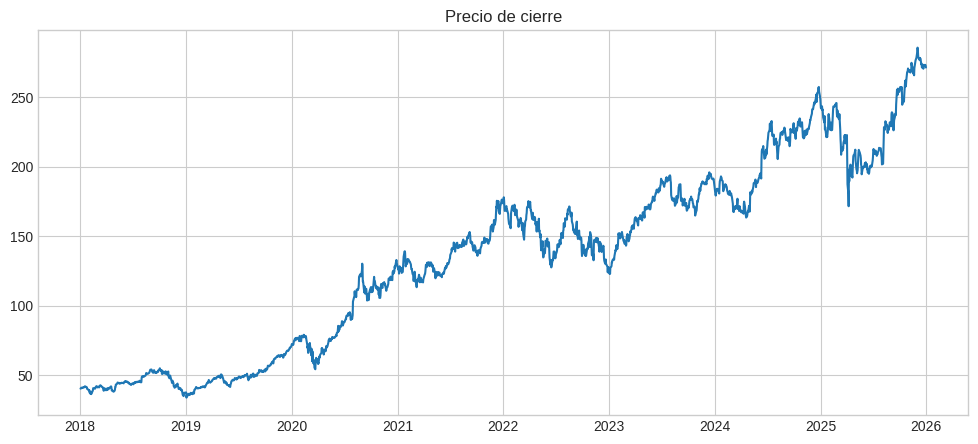

In [17]:
plt.figure(figsize=(12,5))
plt.plot(precio)
plt.title("Precio de cierre")
plt.show()

**ADF Test**

El ADF Test (Prueba de Dickey-Fuller Aumentada) es una prueba estadística que se utiliza en el análisis de series temporales y econometría para determinar si una serie es estacionaria o si contiene una raíz unitaria.

Una serie estacionaria es aquella cuyas propiedades estadísticas (como la media y la varianza) no cambian a lo largo del tiempo, lo cual es requisito para aplicar modelos predictivos como ARIMA.

La prueba evalúa dos posibles escenarios:

*   Hipótesis nula ($H_{0}$): Existe una raíz unitaria. Esto significa que la serie no es estacionaria y depende del tiempo; los datos tienen tendencia o caminan al azar.
*   Hipótesis alternativa ($H_{1}$): No hay raíz unitaria. La serie sí es estacionaria.



In [18]:
resultado = adfuller(precio)

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])

ADF Statistic: -0.27159878425740064
p-value: 0.9294315864391237


Si p-value > 0.05: No podemos rechazar la hipótesis nula. En este caso la serie no es estacionaria (tiene una tendencia o cambia con el tiempo). Necesitas transformarla, esto lo haremos diferenciando la serie y realizando otra vez el test y comparando el p-value.
Como notamos, el p-value fue cercano a 0, entonces la serie ya es estacionaria.

In [19]:
precio_diff = precio.diff().dropna()

In [20]:
resultado = adfuller(precio_diff)

print("p-value:", resultado[1])

p-value: 0.0


Ahora necesitamos ver que modelo de serie de tiempo se parece. Esto lo haremos con la función auto_arima

In [21]:
modelo_auto = auto_arima(
    precio,
    seasonal=False,
    trace=True
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=9575.591, Time=7.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9572.545, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9573.898, Time=0.79 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9573.922, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9574.426, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9576.533, Time=1.15 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 10.580 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2011
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4784.272
Date:                Wed, 22 Jul 2026   AIC                           9572.545
Time:                        23:05:17   BIC                           9583.757
Sample:                             0   HQIC                          9576.661
         

El algoritmo seleccionó un modelo ARIMA(0, 1, 0) con intercepto, indicando que los precios siguen un camino aleatorio con una ligera tendencia al alza a largo plazo. Los diagnósticos confirman la aleatoriedad de los errores, aunque se observa volatilidad extrema típica en datos financieros.

El siguiente código realiza una simulación de predicción paso a paso (conocida en finanzas como Rolling Forecast o Walk-Forward Validation) para evaluar qué tan bueno es el modelo antes de usarlo con dinero real. En lugar de predecir 252 días de golpe, el código predice un solo día a la vez y va actualizando el modelo con el precio real que ocurrió el día anterior, tal como se hace en la vida real.

In [22]:
precio.index = pd.to_datetime(precio.index)

#Establecemos frecuencia de días hábiles ('B') y rellenamos huecos (como días festivos)
precio = precio.asfreq('B')
precio['AAPL'] = precio['AAPL'].ffill()
train = precio[:-252]
test = precio[-252:]
history = train['AAPL'].tolist() # Extrae los valores numericos de la columna'AAPL'
predicciones = []

for t in range(len(test)):

    modelo = ARIMA(history, order=(0,1,0))

    modelo_fit = modelo.fit()

    pred = modelo_fit.forecast()[0]

    predicciones.append(pred)

    history.append(test.iloc[t]['AAPL']) # Añadir el valor Append the numerical value from the 'AAPL' column

In [23]:
#Extracción correcta de la variable objetivo
y_real = test['AAPL']

# Cálculo de errores
mae = mean_absolute_error(y_real, predicciones)
rmse = np.sqrt(mean_squared_error(y_real, predicciones))

print("--- MÉTRICAS DE EVALUACIÓN ---")
print(f"MAE  (Error Absoluto Medio): {mae:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")

--- MÉTRICAS DE EVALUACIÓN ---
MAE  (Error Absoluto Medio): 2.7390
RMSE (Raíz del Error Cuadrático Medio): 4.2412


El MAE indica que en promedio las predicciones diarias del modelo se desvían \$2.74 dólares del precio real de la acción de Apple. Al ser un error bajo en comparación con el precio actual de la acción (que ronda los \$271), indica que el modelo es bastante preciso para el pronóstico inmediato del día a día.

El RMSE mide la magnitud de los errores pero penaliza con fuerza los fallos grandes. En este caso indica que, cuando el modelo se equivoca de forma considerable (debido a caídas o subidas inesperadas de la acción), el error típico se eleva a \$4.24 dólares.

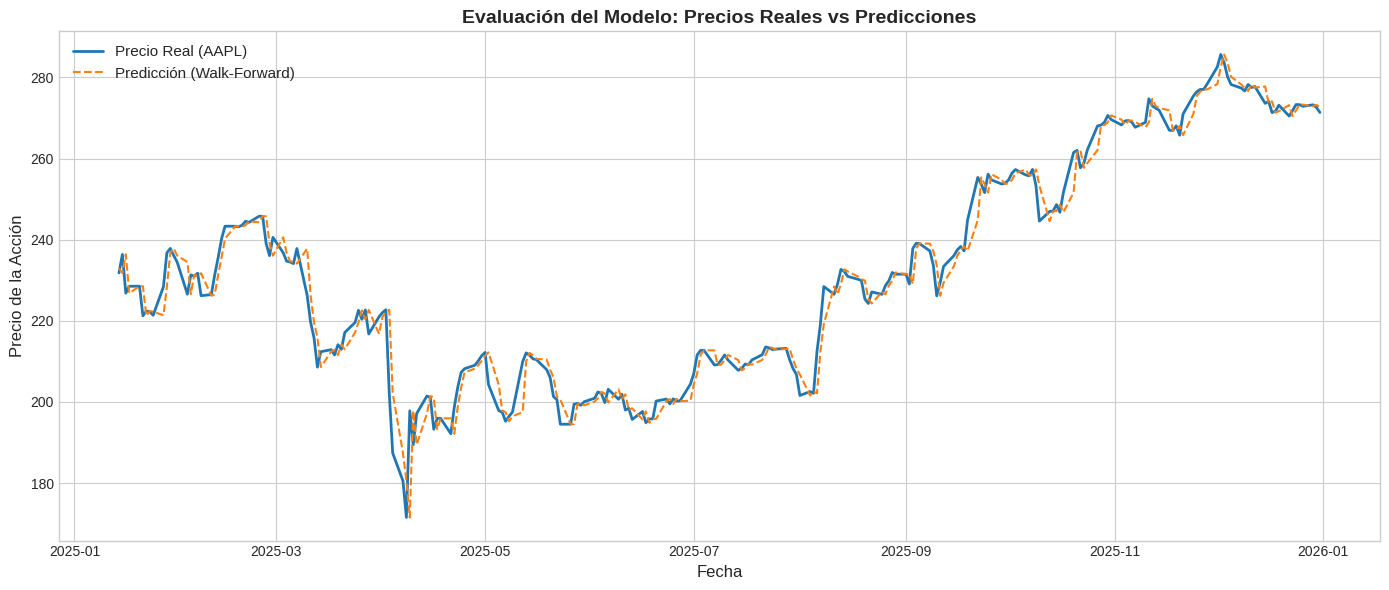

In [24]:
# Gráfica comparativa estilizada
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6), dpi=100)

plt.plot(y_real.index, y_real, label="Precio Real (AAPL)", color='#1f77b4', linewidth=2)
plt.plot(y_real.index, predicciones, label="Predicción (Walk-Forward)", color='#ff7f0e', linestyle='--', linewidth=1.5)

plt.title("Evaluación del Modelo: Precios Reales vs Predicciones", fontsize=14, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio de la Acción", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()


En el comportamiento de las acciones, es completamente normal que el RMSE sea mayor que el MAE. Esto confirma que la acción de Apple experimenta días de alta volatilidad (días con noticias financieras, reportes de ganancias o eventos de mercado) donde el precio rompe la tendencia y se mueve bruscamente, provocando errores aislados más grandes.
Como vemos en la grafica, la predicción de los 252 días mediante el Walk-Forward se parece bastante al precio real, pero no completamente.
Ahora realizamos un pronostico con todos los datos para los siguientes 30 dias hábiles financieros

In [30]:
#Ajuste del modelo final con TODOS los datos
orden_optimo = (0, 1, 0) # resultado de auto_arima

modelo_final = ARIMA(precio['AAPL'], order=(0, 1, 0))
modelo_fit = modelo_final.fit()

# Pronóstico de los próximos 30 días hábiles financieros
forecast = modelo_fit.get_forecast(steps=30)

In [34]:
#Obtener el intervalo de confianza (por defecto 95%)
intervalo_confianza = forecast.summary_frame(alpha=0.05)
#Renombrar columnas
pronostico_detallado = intervalo_confianza[['mean', 'mean_ci_lower', 'mean_ci_upper']]
pronostico_detallado.columns = ['Precio Proyectado', 'Límite Mínimo', 'Límite Máximo']

print("RANGO DE PRECIOS ESPERADOS (95% DE CONFIANZA)")
print(pronostico_detallado.head(10))


RANGO DE PRECIOS ESPERADOS (95% DE CONFIANZA)
            Precio Proyectado  Límite Mínimo  Límite Máximo
2026-01-01         271.355835     266.319748     276.391922
2026-01-02         271.355835     264.233733     278.477937
2026-01-05         271.355835     262.633077     280.078593
2026-01-06         271.355835     261.283661     281.428009
2026-01-07         271.355835     260.094802     282.616867
2026-01-08         271.355835     259.019992     283.691678
2026-01-09         271.355835     258.031602     284.680068
2026-01-12         271.355835     257.111630     285.600040
2026-01-13         271.355835     256.247574     286.464096
2026-01-14         271.355835     255.430330     287.281340
2026-01-15         271.355835     254.653024     288.058645
2026-01-16         271.355835     253.910318     288.801352
2026-01-19         271.355835     253.197966     289.513704
2026-01-20         271.355835     252.512523     290.199147
2026-01-21         271.355835     251.851154     290.8

La anterior tabla, nos muestra el limite minimo y maximo del precio de la accioón, notamos en el limite maximo aumenta constantemente y el limite minimo disminuye constantemente.

Este fenómeno se conoce estadísticamente como efecto abanico (Fan Chart). Significa que el modelo reconoce que es relativamente fácil predecir el precio de mañana (el rango es estrecho, entre $\$266$ y $\$276$), pero a medida que nos alejamos hacia el futuro (por ejemplo 14 de enero), la incertidumbre se expande porque pueden ocurrir demasiados eventos aleatorios en el mercado (el rango se ensancha entre $\$255$ y $\$287$).

Para interpretar cada fila, seria como lo siguiente para el 14 de enero:

*Existe un $95\%$ de probabilidad de que el precio real de la acción de Apple cotice entre $\$255.43$ y $\$287.28$ dólares. El escenario central o más neutral es que se mantenga en $\$271.35$.*

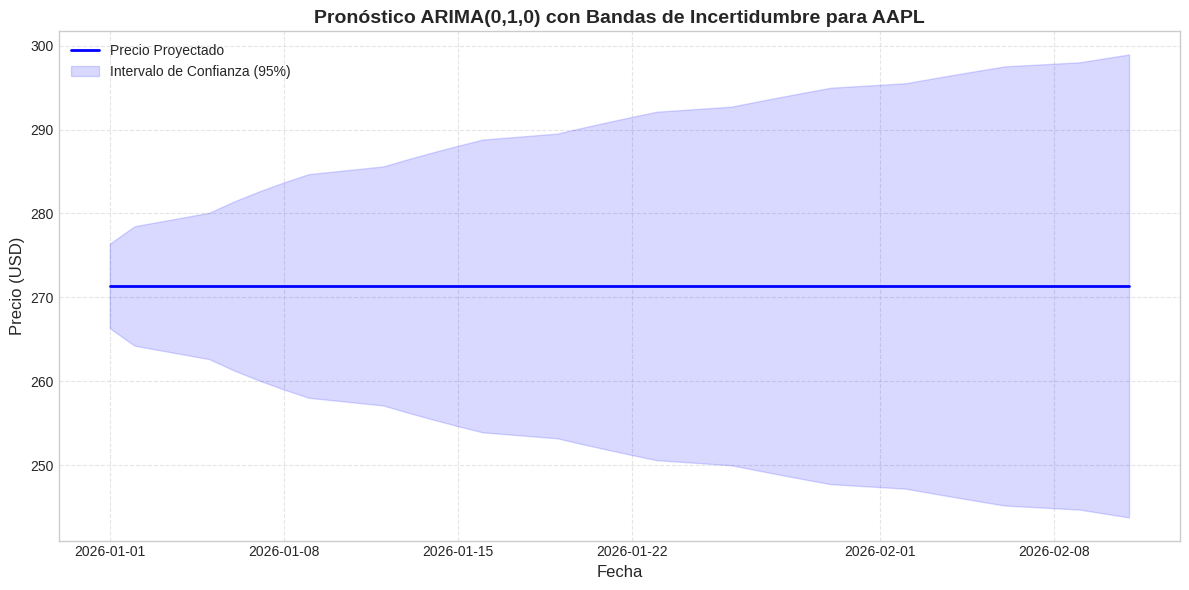

In [35]:
plt.figure(figsize=(12, 6), dpi=100)

# Graficar la línea central del pronóstico
plt.plot(pronostico_detallado.index, pronostico_detallado['Precio Proyectado'],
         label='Precio Proyectado', color='blue', linewidth=2)

# Rellenar el área entre el límite mínimo y máximo (El abanico de incertidumbre)
plt.fill_between(pronostico_detallado.index,
                 pronostico_detallado['Límite Mínimo'],
                 pronostico_detallado['Límite Máximo'],
                 color='blue', alpha=0.15, label='Intervalo de Confianza (95%)')

plt.title('Pronóstico ARIMA(0,1,0) con Bandas de Incertidumbre para AAPL', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Esta gráfica nos permite visualizar el pronóstico del precio de la acción de Apple para los próximos 30 días hábiles, junto con las bandas de incertidumbre del 95%. Como puedes observar:

*   **Línea Azul (Precio Proyectado):** Representa la predicción central del modelo ARIMA(0,1,0). En este caso, al ser un modelo de caminata aleatoria sin tendencia explícita, la predicción se mantiene constante en el último valor observado.
*   **Área Sombreada (Intervalo de Confianza del 95%):** Es el **'efecto abanico'** que mencionamos anteriormente. Esta área representa el rango dentro del cual el precio real de la acción caerá con un 95% de probabilidad. Es crucial notar que este rango se *ensancha* a medida que nos adentramos más en el futuro, reflejando el aumento de la incertidumbre en las predicciones a largo plazo. A corto plazo, el rango es más estrecho y, por lo tanto, la predicción es más precisa.

Esta visualización es muy útil para comunicar no solo la predicción puntual, sino también el nivel de riesgo o incertidumbre asociado a esa predicción, algo fundamental en el análisis financiero.

## Conclusión General del Análisis

Este análisis exploró la predicción del precio de la acción de Apple (AAPL) utilizando modelos de series de  tempor. Los puntos clave de nuestros hallazgos son los siguientes:

1.  **Estacionariedad de la Serie:** Iniciamos el análisis confirmando que la serie de precios de AAPL no era estacionaria, lo cual es común en datos financieros. Tras una diferenciación de primer orden, la serie se volvió estacionaria, lo que permitió la aplicación de modelos ARIMA.

2.  **Selección del Modelo Óptimo (ARIMA(0,1,0)):** Mediante la herramienta `auto_arima`, se identificó el modelo ARIMA(0,1,0) como el más adecuado. Este modelo, también conocido como caminata aleatoria con deriva (debido al intercepto), sugiere que el precio de la acción es principalmente una función de su precio anterior más un ruido aleatorio, y una ligera tendencia.

3.  **Evaluación del Modelo (Walk-Forward Validation):** La validación 'Walk-Forward' demostró que el modelo es razonablemente preciso para predicciones a corto plazo, con un MAE de $\$2.74$ y un RMSE de $\$4.24$. La diferencia entre MAE y RMSE es un buen indicador de la volatilidad en el precio de la acción, ya que el RMSE penaliza más los errores grandes, sugiriendo que existen días con movimientos bruscos en los precios.

4.  **Pronóstico y Bandas de Incertidumbre:** El pronóstico a 30 días hábiles mostró una proyección central constante, típica de un modelo de caminata aleatoria. Sin embargo, la inclusión de las bandas de confianza del 95% reveló el **'efecto abanico'** (fan chart), donde el rango de incertidumbre se amplía significativamente a medida que se extiende el horizonte de pronóstico. Esto subraya que, aunque la predicción puntual puede ser estable, la confianza en esa predicción disminuye considerablemente a largo plazo, destacando la inherentemente alta incertidumbre en los mercados financieros.

En resumen, el modelo ARIMA(0,1,0) proporciona una base sólida para entender y predecir el comportamiento de los precios de AAPL a corto plazo, pero siempre bajo la consideración de la alta volatilidad y la creciente incertidumbre en el futuro. Este análisis sirve como un punto de partida para decisiones de inversión, siempre complementado con otras fuentes de información y análisis de riesgo.